# Решение ДЗ: 6 архитектур нейросетей для задачи регрессии (HeadHunter) — PyTorch

**Задание:** На основе подготовленной таблицы данных HeadHunter создать **6 архитектур** нейросетей, поэкспериментировать с гиперпараметрами. Использовать **только числовые данные** (вектор `x_train_01` размерности 39), текстовые не подавать. В конце — анализ результатов.

**План работы:**
1. Импорт и подготовка данных (повтор раздела «Подготовка»).
2. Нормализация целевой переменной `y_train` (`StandardScaler`).
3. Разделение на обучающую и проверочную выборки + DataLoader-ы.
4. Шесть архитектур, отличающихся:
   - количеством и шириной слоёв,
   - функциями активации,
   - наличием `BatchNorm` / `Dropout`,
   - оптимизатором и `learning_rate`,
   - размером батча и числом эпох.
5. Сводная таблица и графики, итоговый вывод.

**Аналог callback-а в PyTorch.** В Keras обработчик навешивается через `LambdaCallback(on_epoch_end=...)`. В PyTorch цикл обучения мы пишем сами, поэтому «callback» — это просто функция, которую мы вызываем в конце каждой эпохи внутри обучающего цикла. Логика та же: после эпохи делаем `predict` на валидации, обратно денормируем, печатаем MAE в тысячах рублей и сохраняем её в историю.


## 1. Импорты

In [1]:
# Работа с массивами и таблицами
import numpy as np
import pandas as pd

# PyTorch
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

# Прочее
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error
import gdown
import re
import matplotlib.pyplot as plt

%matplotlib inline

# Воспроизводимость
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Используется устройство:', device)


Используется устройство: cuda


## 2. Подготовка данных
Полностью повторяем код раздела «Подготовка» из базового ноутбука: скачиваем CSV, очищаем строки, парсим столбцы и собираем числовой вектор признаков длиной 39.

In [2]:
# Скачиваем базу
gdown.download('https://storage.yandexcloud.net/aiueducation/Content/base/l10/hh_fixed.csv',
               None, quiet=True)

# Чтение
df = pd.read_csv('hh_fixed.csv', index_col=0)
print('Размер исходного датафрейма:', df.shape)
df.head(3)


Размер исходного датафрейма: (62967, 12)


,"Пол, возраст",ЗП,Ищет работу на должность:,Город,Занятость,График,Опыт (двойное нажатие для полной версии),Последенее/нынешнее место работы,Последеняя/нынешняя должность,Образование и ВУЗ,Обновление резюме,Авто
0,"Мужчина , 29 лет , родился 16 мая 1989",40000 руб.,Специалист по поддержке чата(support team) дом...,"Новороссийск , готов к переезду (Анапа, Геленд...",полная занятость,полный день,Опыт работы 3 года 9 месяцев Специалист по по...,"ООО ""Гольфстрим""",Генеральный директор,Высшее образование 2011 Международный юридиче...,26.04.2019 08:04,Не указано
1,"Мужчина , 38 лет , родился 25 мая 1980",40000 руб.,Системный администратор,"Новосибирск , м. Березовая роща , не готов к ...",полная занятость,полный день,Опыт работы 11 лет 11 месяцев Системный админ...,ООО «Завод модульных технологий»,Системный администратор,Высшее образование 2002 Новосибирский государс...,26.04.2019 04:30,Не указано
2,"Мужчина , 35 лет , родился 14 июня 1983",300000 руб.,DevOps TeamLead / DevOps архитектор,"Москва , готов к переезду , готов к редким ком...",полная занятость,полный день,Опыт работы 12 лет 11 месяцев DevOps TeamLead...,Банк ВТБ (ПАО),Начальник отдела методологии разработки (DevOp...,DevOps TeamLead / DevOps архитектор 300 000 ру...,09.04.2019 14:40,Не указано


In [3]:
# Номера столбцов
COL_SEX_AGE  = df.columns.get_loc('Пол, возраст')
COL_SALARY   = df.columns.get_loc('ЗП')
COL_POS_SEEK = df.columns.get_loc('Ищет работу на должность:')
COL_POS_PREV = df.columns.get_loc('Последеняя/нынешняя должность')
COL_CITY     = df.columns.get_loc('Город')
COL_EMPL     = df.columns.get_loc('Занятость')
COL_SCHED    = df.columns.get_loc('График')
COL_EXP      = df.columns.get_loc('Опыт (двойное нажатие для полной версии)')
COL_EDU      = df.columns.get_loc('Образование и ВУЗ')
COL_UPDATED  = df.columns.get_loc('Обновление резюме')


In [4]:
# Очистка строк
def purify(x):
    if isinstance(x, str):
        x = x.replace('\n', ' ').replace('\xa0', '').strip().lower()
    return x

# Применяем
for col in df.columns:
    df[col] = df[col].apply(purify)

# Извлечение года из даты
def extract_year(x):
    try:
        return int(re.search(r'\d\d.\d\d.(\d{4})', x)[1])
    except (IndexError, TypeError, ValueError):
        return 0


In [5]:
# Параметрические данные
currency_rate = {'usd': 65., 'kzt': 0.17, 'грн': 2.6, 'белруб': 30.5,
                 'eur': 70., 'kgs': 0.9, 'сум': 0.007, 'azn': 37.5}

age_class        = [0, [18, 23, 28, 33, 38, 43, 48, 53, 58, 63]]
experience_class = [0, [7, 13, 25, 37, 61, 97, 121, 157, 193, 241]]

city_class = [0,
              {'москва': 0, 'санкт-петербург': 1,
               'новосибирск': 2, 'екатеринбург': 2, 'нижний новгород': 2,
               'казань': 2, 'челябинск': 2, 'омск': 2, 'самара': 2,
               'ростов-на-дону': 2, 'уфа': 2, 'красноярск': 2, 'пермь': 2,
               'воронеж': 2, 'волгоград': 2,
               'прочие города': 3}]

employment_class = [0, {'стажировка': 0, 'частичная занятость': 1,
                        'проектная работа': 2, 'полная занятость': 3}]

schedule_class   = [0, {'гибкий график': 0, 'полный день': 1,
                        'сменный график': 2, 'удаленная работа': 3}]

education_class  = [0, {'высшее образование': 0, 'higher education': 0,
                        'среднее специальное': 1, 'неоконченное высшее': 2,
                        'среднее образование': 3}]

# Подсчёт количества классов
for class_lst in [age_class, experience_class]:
    class_lst[0] = len(class_lst[1]) + 1
for class_dct in [city_class, employment_class, schedule_class, education_class]:
    class_dct[0] = max(class_dct[1].values()) + 1

print('Возраст -', age_class[0], 'классов')
print('Опыт -', experience_class[0], 'классов')
print('Города -', city_class[0], 'классов')


Возраст - 11 классов
Опыт - 11 классов
Города - 4 классов


In [6]:
# Аналог keras.utils.to_categorical в numpy
def to_categorical(idx, num_classes):
    vec = np.zeros(num_classes, dtype=np.float32)
    vec[int(idx)] = 1.
    return vec

# One-hot для целочисленного значения
def int_to_ohe(arg, class_list):
    num_classes = class_list[0]
    for i in range(num_classes - 1):
        if arg < class_list[1][i]:
            cls = i
            break
    else:
        cls = num_classes - 1
    return to_categorical(cls, num_classes)

# Multi-hot из строки и словаря
def str_to_multi(arg, class_dict):
    num_classes = class_dict[0]
    result = np.zeros(num_classes, dtype=np.float32)
    for value, cls in class_dict[1].items():
        if value in arg:
            result[cls] = 1.
    return result


In [7]:
# Парсинг пола и возраста
base_update_year = 2019

def extract_sex_age_years(arg):
    sex = 1. if 'муж' in arg else 0.
    try:
        years = base_update_year - int(re.search(r'\d{4}', arg)[0])
    except (IndexError, TypeError, ValueError):
        years = 0
    return sex, years

def age_years_to_ohe(arg):
    return int_to_ohe(arg, age_class)

def experience_months_to_ohe(arg):
    return int_to_ohe(arg, experience_class)

# Парсинг зарплаты
def extract_salary(arg):
    try:
        value = float(re.search(r'\d+', arg)[0])
        for currency, rate in currency_rate.items():
            if currency in arg:
                value *= rate
                break
    except TypeError:
        value = 0.
    return value / 1000.   # тыс. рублей


In [8]:
# Город -> one-hot
def extract_city_to_ohe(arg):
    num_classes = city_class[0]
    split_array = re.split(r'[ ,.:()?!]', arg)
    for word in split_array:
        city_cls = city_class[1].get(word, -1)
        if city_cls >= 0:
            break
    else:
        city_cls = num_classes - 1
    return to_categorical(city_cls, num_classes)

# Multi-hot для занятости / графика / образования
def extract_employment_to_multi(arg):
    return str_to_multi(arg, employment_class)

def extract_schedule_to_multi(arg):
    return str_to_multi(arg, schedule_class)

def extract_education_to_multi(arg):
    result = str_to_multi(arg, education_class)
    if result[2] > 0.:           # неоконченное высшее ⇒ убираем «высшее»
        result[0] = 0.
    return result

# Опыт работы (месяцев)
def extract_experience_months(arg):
    try:
        years = int(re.search(r'(\d+)\s+(год.?|лет)', arg)[1])
    except (IndexError, TypeError, ValueError):
        years = 0
    try:
        months = int(re.search(r'(\d+)\s+месяц', arg)[1])
    except (IndexError, TypeError, ValueError):
        months = 0
    return years * 12 + months


In [9]:
# Сборка одной строки
def extract_row_data(row):
    sex, age = extract_sex_age_years(row[COL_SEX_AGE])
    sex_vec   = np.array([sex], dtype=np.float32)
    age_ohe   = age_years_to_ohe(age)
    city_ohe  = extract_city_to_ohe(row[COL_CITY])
    empl_mult = extract_employment_to_multi(row[COL_EMPL])
    sched_mlt = extract_schedule_to_multi(row[COL_SCHED])
    edu_multi = extract_education_to_multi(row[COL_EDU])
    exp_mon   = extract_experience_months(row[COL_EXP])
    exp_ohe   = experience_months_to_ohe(exp_mon)
    salary    = extract_salary(row[COL_SALARY])
    salary_v  = np.array([salary], dtype=np.float32)

    x_data = np.hstack([sex_vec, age_ohe, city_ohe,
                        empl_mult, sched_mlt, edu_multi, exp_ohe])
    return x_data, salary_v

# Сбор всей выборки
def construct_train_data(row_list):
    x_data, y_data = [], []
    for row in row_list:
        x, y = extract_row_data(row)
        if y[0] > 0:
            x_data.append(x)
            y_data.append(y)
    return np.array(x_data, dtype=np.float32), np.array(y_data, dtype=np.float32)


In [10]:
# Формируем выборку
x_train_01, y_train = construct_train_data(df.values)
print('x_train_01.shape =', x_train_01.shape)
print('y_train.shape    =', y_train.shape)
print('Пример x:', x_train_01[0])
print('Пример y:', y_train[0])


x_train_01.shape = (62967, 39)
y_train.shape    = (62967, 1)
Пример x: [1. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 1. 0. 1. 0. 0.
 1. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
Пример y: [40.]


## 3. Нормализация целевой переменной и DataLoader-ы
Зарплату нормируем (`StandardScaler`) — это сильно ускоряет сходимость регрессии. После каждого обучения денормируем предсказание и считаем ошибку в **тысячах рублей**.

В PyTorch нет `validation_split=0.15` как в Keras — мы вручную делим выборку маской и заворачиваем в `TensorDataset` + `DataLoader`.

In [11]:
# Нормализация y
y_scaler = StandardScaler()
y_train_scaled = y_scaler.fit_transform(y_train).astype(np.float32)

print('mean ≈', round(y_train_scaled.mean(), 4),
      ', std ≈', round(y_train_scaled.std(), 4))


mean ≈ -0.0 , std ≈ 1.0


In [12]:
# Разделение по маске (~15% валидации)
np.random.seed(SEED)
val_mask = np.random.rand(len(x_train_01)) < 0.15
print('Train:', (~val_mask).sum(), '   Val:', val_mask.sum())

x_tr,  x_val  = x_train_01[~val_mask], x_train_01[val_mask]
y_tr,  y_val  = y_train_scaled[~val_mask], y_train_scaled[val_mask]
y_val_orig    = y_train[val_mask]  # для финальной денормированной MAE

# В тензоры
x_tr_t   = torch.from_numpy(x_tr).float()
y_tr_t   = torch.from_numpy(y_tr).float()
x_val_t  = torch.from_numpy(x_val).float().to(device)
y_val_t  = torch.from_numpy(y_val).float().to(device)

INPUT_DIM = x_train_01.shape[1]
print('INPUT_DIM =', INPUT_DIM)


Train: 53543    Val: 9424
INPUT_DIM = 39


## 4. Универсальный обучающий цикл

В Keras одна строчка `model.fit(...)` делает всё. В PyTorch цикл обучения пишем сами:

1. Каждую эпоху проходим train в режиме `model.train()`, делаем `forward → loss → backward → optimizer.step()`.
2. После эпохи переключаем `model.eval()`, считаем MAE на train (нормированную) и на val (нормированную и в тыс. руб.).
3. Аналог Keras-callback-а — функция `epoch_callback`, которую вызываем в конце эпохи.

Это даёт нам полный контроль и ту же логику, что и в Keras-версии.

In [13]:
def train_model(model, optimizer, x_tr, y_tr, x_val_t, y_val_t,
                y_val_orig, y_scaler,
                epochs=30, batch_size=128, verbose_every=10):
    """Универсальный обучающий цикл с историей MAE (как Keras history)."""
    model = model.to(device)
    criterion = nn.MSELoss()

    # DataLoader для train
    train_ds = TensorDataset(x_tr, y_tr)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)

    history = {'mae': [], 'val_mae': []}    # нормированный MAE (как в Keras)
    rub_history = []                        # MAE в тыс. руб. на валидации

    for epoch in range(epochs):
        # ---- train ----
        model.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            pred = model(xb)
            loss = criterion(pred, yb)
            loss.backward()
            optimizer.step()

        # ---- метрики на train и val (после эпохи) ----
        model.eval()
        with torch.no_grad():
            # train MAE (нормированный)
            preds_tr = []
            for xb, _ in DataLoader(train_ds, batch_size=1024):
                preds_tr.append(model(xb.to(device)).cpu().numpy())
            preds_tr = np.concatenate(preds_tr, axis=0)
            mae_tr = float(np.mean(np.abs(preds_tr - y_tr.numpy())))

            # val MAE (нормированный)
            preds_val = model(x_val_t).cpu().numpy()
            mae_val = float(np.mean(np.abs(preds_val - y_val_t.cpu().numpy())))

            # val MAE в тыс. руб.
            preds_val_rub = y_scaler.inverse_transform(preds_val)
            mae_rub = float(np.mean(np.abs(preds_val_rub - y_val_orig)))

        history['mae'].append(mae_tr)
        history['val_mae'].append(mae_val)
        rub_history.append(mae_rub)

        # Аналог Keras-callback-а: печать в конце эпохи
        if (epoch + 1) % verbose_every == 0 or epoch == 0:
            print(f'  Эпоха {epoch+1:3d}/{epochs} | '
                  f'MAE train={mae_tr:.4f}  val={mae_val:.4f}  | '
                  f'MAE val (тыс. руб.) = {mae_rub:6.2f}')

    return history, rub_history


In [14]:
def plot_history(history, title=''):
    plt.figure(figsize=(8, 4))
    plt.plot(history['mae'],     label='MAE train')
    plt.plot(history['val_mae'], label='MAE val')
    plt.title(title)
    plt.xlabel('Эпоха обучения')
    plt.ylabel('MAE (нормированная)')
    plt.legend(); plt.grid(); plt.show()

def eval_net_scaled(model, x_val_t, y_val_orig, y_scaler):
    model.eval()
    with torch.no_grad():
        preds = model(x_val_t).cpu().numpy()
    preds = y_scaler.inverse_transform(preds)
    return mean_absolute_error(y_val_orig, preds), preds


In [15]:
# Здесь будут результаты всех 6 моделей
results = []  # [{name, params, mae, history, rub_history}]


## 5. Шесть архитектур

Все 6 моделей получают **один и тот же** числовой вход размерности 39 и предсказывают зарплату (на выходе один линейный нейрон, loss = MSE, метрика = MAE).
Различаются — глубина / ширина / активация / регуляризация / оптимизатор / batch_size / эпохи.

| № | Главная идея |
|---|---|
| 1 | Маленькая базовая сеть (2 слоя, ReLU, Adam) — старт, baseline |
| 2 | Глубокая сеть с BatchNorm (4 слоя) |
| 3 | Очень широкая сеть (1 скрытый слой по 1024) |
| 4 | Сеть с Dropout — регуляризация против переобучения |
| 5 | Tanh + Adagrad — другой оптимизатор и активация |
| 6 | Глубокая «пирамидальная» сеть с BN + Dropout, RMSprop |

### Модель 1 — базовая (минимальная)
**Гиперпараметры:** 2 слоя по 64 / 32, активация `ReLU`, оптимизатор `Adam(lr=1e-3)`, `batch_size=128`, 30 эпох. Без регуляризации — точка отсчёта.

=== M1 baseline (Linear 64-32, Adam 1e-3) ===
  Эпоха   1/30 | MAE train=0.2679  val=0.2664  | MAE val (тыс. руб.) =  32.55
  Эпоха   5/30 | MAE train=0.2608  val=0.2597  | MAE val (тыс. руб.) =  31.73
  Эпоха  10/30 | MAE train=0.2547  val=0.2539  | MAE val (тыс. руб.) =  31.02
  Эпоха  15/30 | MAE train=0.2574  val=0.2574  | MAE val (тыс. руб.) =  31.45
  Эпоха  20/30 | MAE train=0.2598  val=0.2600  | MAE val (тыс. руб.) =  31.77
  Эпоха  25/30 | MAE train=0.2575  val=0.2579  | MAE val (тыс. руб.) =  31.51
  Эпоха  30/30 | MAE train=0.2538  val=0.2546  | MAE val (тыс. руб.) =  31.11

Итоговый MAE (тыс. руб.): 31.11


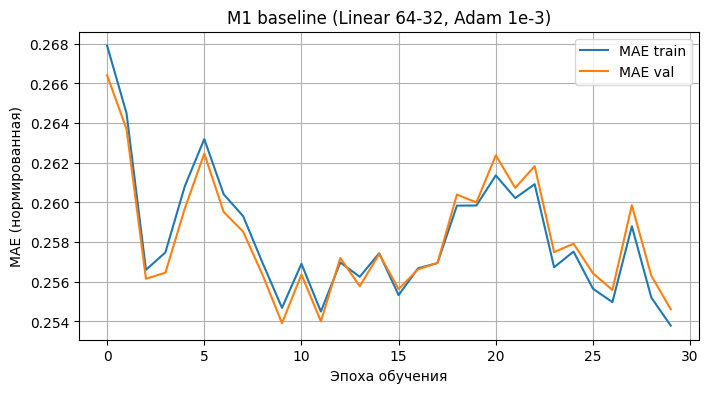

In [16]:
name1 = 'M1 baseline (Linear 64-32, Adam 1e-3)'
print('=== ' + name1 + ' ===')

torch.manual_seed(SEED)
m1 = nn.Sequential(
    nn.Linear(INPUT_DIM, 64), nn.ReLU(),
    nn.Linear(64, 32),        nn.ReLU(),
    nn.Linear(32, 1),
)
opt1 = torch.optim.Adam(m1.parameters(), lr=1e-3)

h1, rub1 = train_model(m1, opt1, x_tr_t, y_tr_t, x_val_t, y_val_t,
                       y_val_orig, y_scaler,
                       epochs=30, batch_size=128, verbose_every=5)

mae1, _ = eval_net_scaled(m1, x_val_t, y_val_orig, y_scaler)
print(f'\nИтоговый MAE (тыс. руб.): {mae1:.2f}')
plot_history(h1, name1)

results.append({'name': name1,
                'params': '2×Linear (64,32), Adam 1e-3, bs=128, ep=30',
                'mae': mae1, 'history': h1, 'rub_history': rub1})


### Модель 2 — глубокая с BatchNorm
**Гиперпараметры:** 4 скрытых слоя (256→128→64→32), `BatchNorm1d` после входа, активация `ReLU`, `Adam(lr=1e-3)`, `batch_size=256`, 50 эпох.
Идея: больше глубины + BN стабилизирует обучение.

=== M2 deep+BN (256-128-64-32, Adam 1e-3) ===
  Эпоха   1/50 | MAE train=0.2642  val=0.2644  | MAE val (тыс. руб.) =  32.30
  Эпоха  10/50 | MAE train=0.2542  val=0.2548  | MAE val (тыс. руб.) =  31.13
  Эпоха  20/50 | MAE train=0.2575  val=0.2619  | MAE val (тыс. руб.) =  31.99
  Эпоха  30/50 | MAE train=0.2506  val=0.2580  | MAE val (тыс. руб.) =  31.52
  Эпоха  40/50 | MAE train=0.2462  val=0.2578  | MAE val (тыс. руб.) =  31.49
  Эпоха  50/50 | MAE train=0.2416  val=0.2569  | MAE val (тыс. руб.) =  31.39

Итоговый MAE (тыс. руб.): 31.39


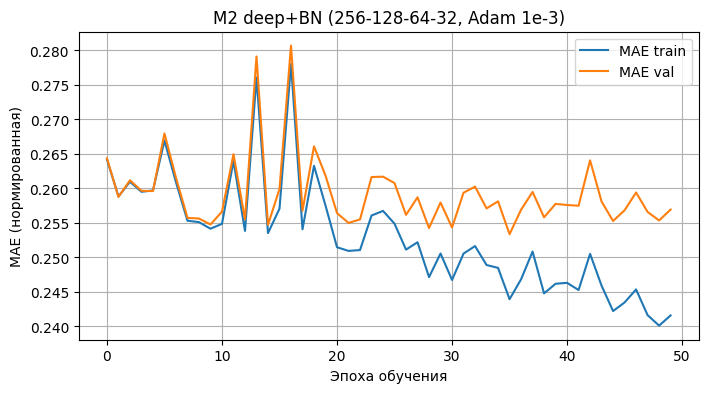

In [17]:
name2 = 'M2 deep+BN (256-128-64-32, Adam 1e-3)'
print('=== ' + name2 + ' ===')

torch.manual_seed(SEED)
m2 = nn.Sequential(
    nn.BatchNorm1d(INPUT_DIM),
    nn.Linear(INPUT_DIM, 256), nn.ReLU(),
    nn.Linear(256, 128),       nn.ReLU(),
    nn.Linear(128, 64),        nn.ReLU(),
    nn.Linear(64, 32),         nn.ReLU(),
    nn.Linear(32, 1),
)
opt2 = torch.optim.Adam(m2.parameters(), lr=1e-3)

h2, rub2 = train_model(m2, opt2, x_tr_t, y_tr_t, x_val_t, y_val_t,
                       y_val_orig, y_scaler,
                       epochs=50, batch_size=256, verbose_every=10)

mae2, _ = eval_net_scaled(m2, x_val_t, y_val_orig, y_scaler)
print(f'\nИтоговый MAE (тыс. руб.): {mae2:.2f}')
plot_history(h2, name2)

results.append({'name': name2,
                'params': 'BN + 4 Linear (256,128,64,32), Adam 1e-3, bs=256, ep=50',
                'mae': mae2, 'history': h2, 'rub_history': rub2})


### Модель 3 — широкая (1 большой скрытый слой)
**Гиперпараметры:** один скрытый слой `Linear(1024) + ReLU`, далее `Linear(64)`, `Adam(lr=5e-4)`, `batch_size=512`, 40 эпох.
Идея: проверить, помогает ли «ширина» при ограниченном входе (39 признаков).

=== M3 wide (1024-64, Adam 5e-4) ===
  Эпоха   1/40 | MAE train=0.2566  val=0.2553  | MAE val (тыс. руб.) =  31.19
  Эпоха  10/40 | MAE train=0.2551  val=0.2551  | MAE val (тыс. руб.) =  31.17
  Эпоха  20/40 | MAE train=0.2592  val=0.2607  | MAE val (тыс. руб.) =  31.86
  Эпоха  30/40 | MAE train=0.2798  val=0.2826  | MAE val (тыс. руб.) =  34.53
  Эпоха  40/40 | MAE train=0.2558  val=0.2604  | MAE val (тыс. руб.) =  31.82

Итоговый MAE (тыс. руб.): 31.82


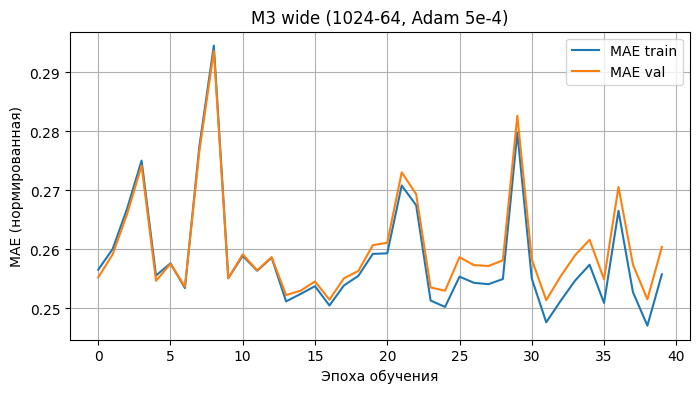

In [18]:
name3 = 'M3 wide (1024-64, Adam 5e-4)'
print('=== ' + name3 + ' ===')

torch.manual_seed(SEED)
m3 = nn.Sequential(
    nn.Linear(INPUT_DIM, 1024), nn.ReLU(),
    nn.Linear(1024, 64),        nn.ReLU(),
    nn.Linear(64, 1),
)
opt3 = torch.optim.Adam(m3.parameters(), lr=5e-4)

h3, rub3 = train_model(m3, opt3, x_tr_t, y_tr_t, x_val_t, y_val_t,
                       y_val_orig, y_scaler,
                       epochs=40, batch_size=512, verbose_every=10)

mae3, _ = eval_net_scaled(m3, x_val_t, y_val_orig, y_scaler)
print(f'\nИтоговый MAE (тыс. руб.): {mae3:.2f}')
plot_history(h3, name3)

results.append({'name': name3,
                'params': 'Linear 1024-64, Adam 5e-4, bs=512, ep=40',
                'mae': mae3, 'history': h3, 'rub_history': rub3})


### Модель 4 — Dropout-регуляризация
**Гиперпараметры:** 3 слоя (256→128→64) с `Dropout(0.3)` после каждого, `Adam(lr=1e-3)`, `batch_size=128`, 60 эпох.
Идея: Dropout должен препятствовать переобучению.

=== M4 dropout (256-128-64 + Dropout 0.3) ===
  Эпоха   1/60 | MAE train=0.2616  val=0.2605  | MAE val (тыс. руб.) =  31.83
  Эпоха  10/60 | MAE train=0.2862  val=0.2855  | MAE val (тыс. руб.) =  34.89
  Эпоха  20/60 | MAE train=0.2568  val=0.2585  | MAE val (тыс. руб.) =  31.58
  Эпоха  30/60 | MAE train=0.2561  val=0.2600  | MAE val (тыс. руб.) =  31.76
  Эпоха  40/60 | MAE train=0.2530  val=0.2568  | MAE val (тыс. руб.) =  31.38
  Эпоха  50/60 | MAE train=0.2507  val=0.2555  | MAE val (тыс. руб.) =  31.22
  Эпоха  60/60 | MAE train=0.2558  val=0.2618  | MAE val (тыс. руб.) =  31.99

Итоговый MAE (тыс. руб.): 31.99


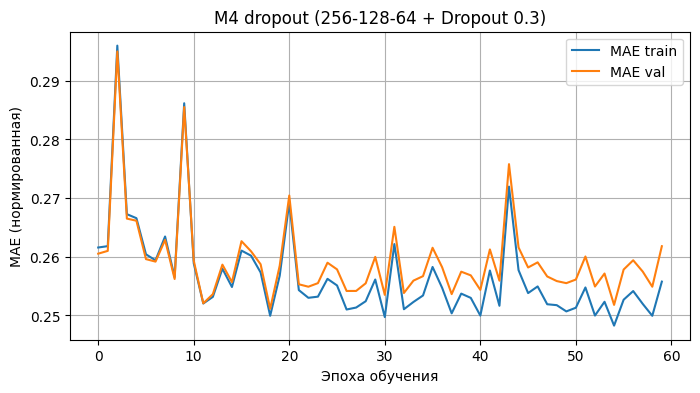

In [19]:
name4 = 'M4 dropout (256-128-64 + Dropout 0.3)'
print('=== ' + name4 + ' ===')

torch.manual_seed(SEED)
m4 = nn.Sequential(
    nn.Linear(INPUT_DIM, 256), nn.ReLU(), nn.Dropout(0.3),
    nn.Linear(256, 128),       nn.ReLU(), nn.Dropout(0.3),
    nn.Linear(128, 64),        nn.ReLU(), nn.Dropout(0.3),
    nn.Linear(64, 1),
)
opt4 = torch.optim.Adam(m4.parameters(), lr=1e-3)

h4, rub4 = train_model(m4, opt4, x_tr_t, y_tr_t, x_val_t, y_val_t,
                       y_val_orig, y_scaler,
                       epochs=60, batch_size=128, verbose_every=10)

mae4, _ = eval_net_scaled(m4, x_val_t, y_val_orig, y_scaler)
print(f'\nИтоговый MAE (тыс. руб.): {mae4:.2f}')
plot_history(h4, name4)

results.append({'name': name4,
                'params': 'Linear 256-128-64, Dropout 0.3, Adam 1e-3, bs=128, ep=60',
                'mae': mae4, 'history': h4, 'rub_history': rub4})


### Модель 5 — Tanh + Adagrad
**Гиперпараметры:** 3 слоя (200 `Tanh` → 100 `ReLU` → 50 `ReLU`), оптимизатор `Adagrad(lr=1e-2)`, `batch_size=64`, 40 эпох.
Идея: проверить вариант с другой активацией и оптимизатором — `Tanh` ограничивает выход скрытых нейронов, `Adagrad` хорошо работает с разреженными признаками (а у нас как раз one-hot/multi-hot).

=== M5 Tanh+Adagrad (200-100-50, Adagrad 1e-2) ===
  Эпоха   1/40 | MAE train=0.2623  val=0.2612  | MAE val (тыс. руб.) =  31.91
  Эпоха  10/40 | MAE train=0.2573  val=0.2568  | MAE val (тыс. руб.) =  31.37
  Эпоха  20/40 | MAE train=0.2574  val=0.2577  | MAE val (тыс. руб.) =  31.49
  Эпоха  30/40 | MAE train=0.2569  val=0.2583  | MAE val (тыс. руб.) =  31.56
  Эпоха  40/40 | MAE train=0.2544  val=0.2564  | MAE val (тыс. руб.) =  31.33

Итоговый MAE (тыс. руб.): 31.33


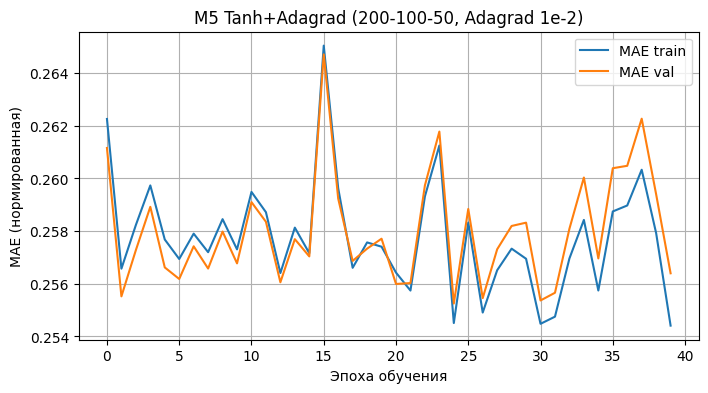

In [22]:
name5 = 'M5 Tanh+Adagrad (200-100-50, Adagrad 1e-2)'
print('=== ' + name5 + ' ===')

torch.manual_seed(SEED)
m5 = nn.Sequential(
    nn.Linear(INPUT_DIM, 200), nn.Tanh(),
    nn.Linear(200, 100),       nn.ReLU(),
    nn.Linear(100, 50),        nn.ReLU(),
    nn.Linear(50, 1),
)
m5.to(device) # Moved model to device before initializing optimizer
opt5 = torch.optim.Adagrad(m5.parameters(), lr=1e-2)

h5, rub5 = train_model(m5, opt5, x_tr_t, y_tr_t, x_val_t, y_val_t,
                       y_val_orig, y_scaler,
                       epochs=40, batch_size=64, verbose_every=10)

mae5, _ = eval_net_scaled(m5, x_val_t, y_val_orig, y_scaler)
print(f'\nИтоговый MAE (тыс. руб.): {mae5:.2f}')
plot_history(h5, name5)

results.append({'name': name5,
                'params': '200(Tanh)-100-50, Adagrad 1e-2, bs=64, ep=40',
                'mae': mae5, 'history': h5, 'rub_history': rub5})

### Модель 6 — пирамидальная глубокая (BN + Dropout, RMSprop)
**Гиперпараметры:** 5 скрытых слоёв (512→256→128→64→32) с `BatchNorm1d` и `Dropout(0.2)` между ними, оптимизатор `RMSprop(lr=5e-4)`, `batch_size=256`, 80 эпох.
Идея: «всё и сразу» — глубина + BN + Dropout + другой оптимизатор. Самая ёмкая модель в сравнении.

=== M6 deep pyramid (BN+Dropout, RMSprop 5e-4) ===
  Эпоха   1/80 | MAE train=0.2565  val=0.2558  | MAE val (тыс. руб.) =  31.25
  Эпоха  10/80 | MAE train=0.2569  val=0.2588  | MAE val (тыс. руб.) =  31.62
  Эпоха  20/80 | MAE train=0.2482  val=0.2508  | MAE val (тыс. руб.) =  30.64
  Эпоха  30/80 | MAE train=0.2527  val=0.2562  | MAE val (тыс. руб.) =  31.31
  Эпоха  40/80 | MAE train=0.2465  val=0.2519  | MAE val (тыс. руб.) =  30.77
  Эпоха  50/80 | MAE train=0.2493  val=0.2557  | MAE val (тыс. руб.) =  31.24
  Эпоха  60/80 | MAE train=0.2524  val=0.2601  | MAE val (тыс. руб.) =  31.78
  Эпоха  70/80 | MAE train=0.2470  val=0.2551  | MAE val (тыс. руб.) =  31.17
  Эпоха  80/80 | MAE train=0.2443  val=0.2546  | MAE val (тыс. руб.) =  31.11

Итоговый MAE (тыс. руб.): 31.11


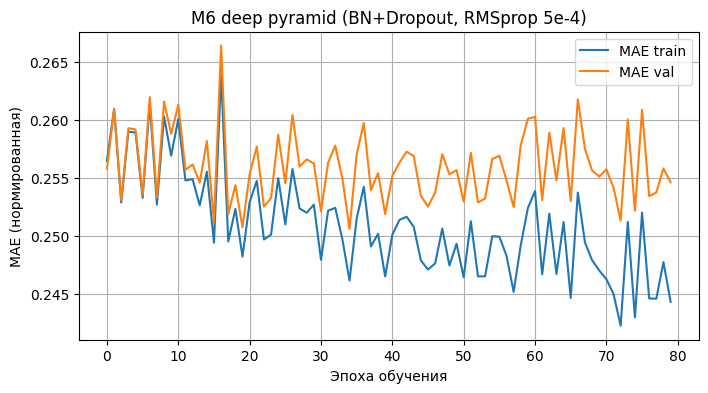

In [23]:
name6 = 'M6 deep pyramid (BN+Dropout, RMSprop 5e-4)'
print('=== ' + name6 + ' ===')

torch.manual_seed(SEED)
m6 = nn.Sequential(
    nn.Linear(INPUT_DIM, 512), nn.BatchNorm1d(512), nn.ReLU(), nn.Dropout(0.2),
    nn.Linear(512, 256),       nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(0.2),
    nn.Linear(256, 128),       nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.2),
    nn.Linear(128, 64),        nn.BatchNorm1d(64),  nn.ReLU(),
    nn.Linear(64, 32),                              nn.ReLU(),
    nn.Linear(32, 1),
)
opt6 = torch.optim.RMSprop(m6.parameters(), lr=5e-4)

h6, rub6 = train_model(m6, opt6, x_tr_t, y_tr_t, x_val_t, y_val_t,
                       y_val_orig, y_scaler,
                       epochs=80, batch_size=256, verbose_every=10)

mae6, _ = eval_net_scaled(m6, x_val_t, y_val_orig, y_scaler)
print(f'\nИтоговый MAE (тыс. руб.): {mae6:.2f}')
plot_history(h6, name6)

results.append({'name': name6,
                'params': '5 Linear пирамида + BN + Dropout 0.2, RMSprop 5e-4, bs=256, ep=80',
                'mae': mae6, 'history': h6, 'rub_history': rub6})


## 6. Сводный анализ результатов

In [24]:
# Таблица результатов
summary = pd.DataFrame([
    {'Модель': r['name'],
     'Гиперпараметры': r['params'],
     'MAE val (тыс. руб.)': round(r['mae'], 2)}
    for r in results
])
summary = summary.sort_values('MAE val (тыс. руб.)').reset_index(drop=True)
summary


,Модель,Гиперпараметры,MAE val (тыс. руб.)
0,"M1 baseline (Linear 64-32, Adam 1e-3)","2×Linear (64,32), Adam 1e-3, bs=128, ep=30",31.11
1,"M6 deep pyramid (BN+Dropout, RMSprop 5e-4)","5 Linear пирамида + BN + Dropout 0.2, RMSprop ...",31.11
2,"M5 Tanh+Adagrad (200-100-50, Adagrad 1e-2)","200(Tanh)-100-50, Adagrad 1e-2, bs=64, ep=40",31.33
3,"M2 deep+BN (256-128-64-32, Adam 1e-3)","BN + 4 Linear (256,128,64,32), Adam 1e-3, bs=2...",31.39
4,"M3 wide (1024-64, Adam 5e-4)","Linear 1024-64, Adam 5e-4, bs=512, ep=40",31.82
5,M4 dropout (256-128-64 + Dropout 0.3),"Linear 256-128-64, Dropout 0.3, Adam 1e-3, bs=...",31.99


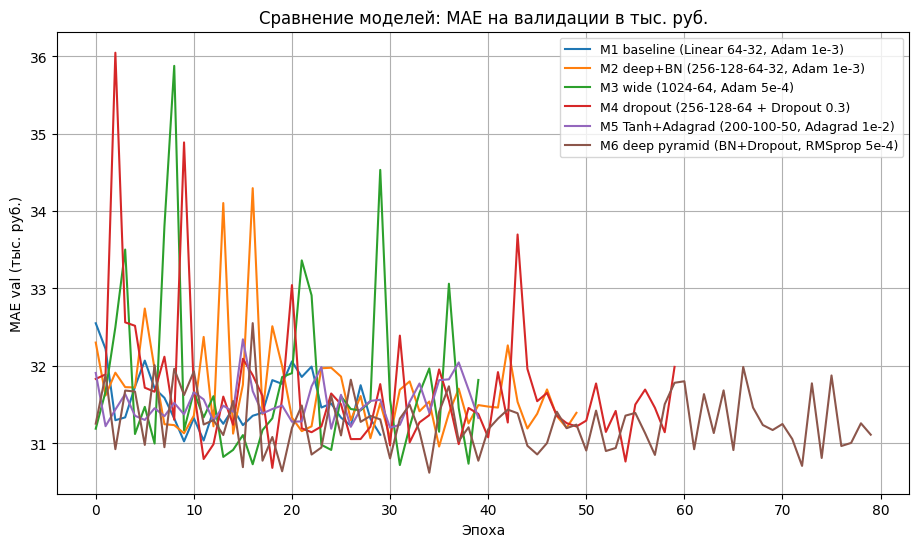

In [25]:
# График сравнения MAE (в тыс. руб.) по эпохам — все 6 моделей
plt.figure(figsize=(11, 6))
for r in results:
    plt.plot(r['rub_history'], label=r['name'])
plt.xlabel('Эпоха')
plt.ylabel('MAE val (тыс. руб.)')
plt.title('Сравнение моделей: MAE на валидации в тыс. руб.')
plt.legend(loc='upper right', fontsize=9)
plt.grid(); plt.show()


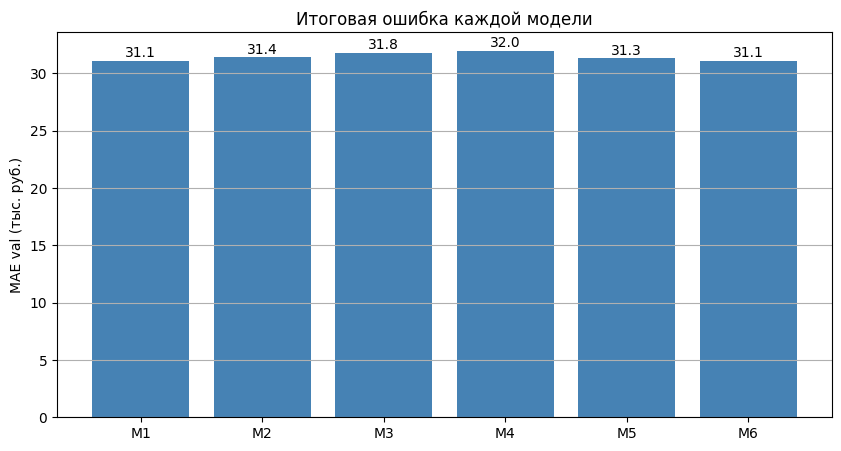

In [26]:
# Бар-чарт итоговых ошибок
plt.figure(figsize=(10, 5))
plt.bar(range(len(results)),
        [r['mae'] for r in results],
        color='steelblue')
plt.xticks(range(len(results)),
           [f'M{i+1}' for i in range(len(results))])
plt.ylabel('MAE val (тыс. руб.)')
plt.title('Итоговая ошибка каждой модели')
for i, r in enumerate(results):
    plt.text(i, r['mae'] + 0.3, f"{r['mae']:.1f}",
             ha='center', fontsize=10)
plt.grid(axis='y'); plt.show()
